# **PROYECTO FINAL- SINIESTROS VIALES 2015-2020 - SiniBogotá**

**Curso Aprendizaje de Máquinas**

**Integrantes:**

*   Santiago Orjuela - santiago_orjuela@javeriana.edu.co
*   Laura Beltran Arias - beltranla@javeriana.edu.co
*   Nicolas Avila - avila.bnicolas@javeriana.edu.co




## **Modelo XGBoost (eXtreme Gradient Boosting)**

## **Planeación**

### Contexto:

La seguridad vial constituye uno de los principales retos de gestión pública en Bogotá, donde la alta densidad poblacional, el aumento en el uso de vehiculos y la diversidad de actores viales generan condiciones complejas de movilidad.

Para darnos una idea, entre 2021 y 2024, las muertes por siniestros viales en Bogotá presentaron un aumento sostenido, solo para 2025 se ha logrado una reducción cercana al 2% frente al 2024, esto segun estudios del Observatorio Nacional de Seguridad Vial. (11 Feb 2026, Bogota.Gov.co, Gina R Sánchez)

En adición, durante los últimos años, la ciudad ha experimentado eventos atípicos y restricciones sin precedentes, como las medidas de confinamiento por la pandemia de COVID-19, jornadas de “día sin carro”, protestas sociales y variaciones significativas en la movilidad urbana.


Estos eventos alteran drásticamente:

- El volumen de tráfico

- Los patrones de desplazamiento

- El comportamiento de los actores viales

- La capacidad de control por parte de las autoridades

Sin embargo, no es claro si estas variaciones generan reducciones sostenidas en la frecuencia de siniestros, cambios en la severidad de los mismos o efectos temporales o estructurales frente al comportamiento de los usuarios.

Por si fuera poco, aunque el Distrito impone miles de comparendos cada año como mecanismo de control y disuasión, no existe evidencia clara de su impacto real en la reducción de la siniestralidad.


### Fuentes de Datos:

**Set Principal**

Los datos de siniestros viales en Bogotá que cubren el periodo comprendido entre el 1 de enero de 2015 y el 31 de diciembre de 2020.


***Fuente:***
Secretaría Distrital de Movilidad

Este data set esta distribuido en cinco tablas:

1.   Siniestros: Detalles del Siniestro
2.   Actores Viales: Detalles de los actores viales afectados
3.   Vehiculos: Detalles de los vehiculos
4.   Hipotesis: Código causa
5.   Diccionario: Descripciones de los sets anteriores


**Datos Complementarios**

Tenemos los siguientes data sets complementarios:

1. **Calendario 2015-2020** Contiene el día de la semana, si es festivo, si hay día sin carro, si hay covid, si hay protesta o algun evento relevante.
Fuente: Creado manualmente.


2. **Clima 2015-2020** La fuente IDEAM aporta observaciones diarias de precipitación por estación en la ciudad de Bogotá, extrayendo datos en un período de tiempo del año 2015 al 2020.



**Nota:** Todos los datasets los hemos subido a Git hub.

## **Estrategia de Integración de Datos**

Para enriquecer el análisis utilizaremos una estrategia de unión por cada una de los sets de datos.  

**Estrategia de Integración** (Relaciones 1:N)

### Set Principal (Siniestros)

La base de datos de siniestros viales constituye el eje central del estudio, ya que contiene información detallada sobre la ocurrencia, severidad, localización y características de los accidentes en Bogotá.


- **Set Calendario:**
Relación: 1 a 1.
Cruce directo por FECHA para etiquetar el contexto de cada accidente.

- **Set de Vehículos:**
Relación: 1 a Varios. Un CODIGO_ACCIDENTE puede tener varios vehículos.

   Estrategia: Se debe decidir si se aplana la base (contar cuántos vehículos hubo por accidente) o si se mantiene el detalle para analizar fallas mecánicas por tipo de vehículo.

- **Set de Actor Vial:**
Relación: 1 a Varios. Un accidente involucra a varias personas con diferentes roles.

  Estrategia: Cruce por CODIGO_ACCIDENTE. Es vital para identificar, por ejemplo, cuántos heridos hubo por cada tipo de vehículo involucrado.

- **Set de Hipótesis:**
Relación: 1 a Varios. Un accidente puede tener múltiples causas (ej. Lluvia + Embriaguez).

### Set Complementario 1 (Calendario 2015-2020)

El calendario de eventos especiales y restricciones de movilidad permite contextualizar los siniestros dentro de dinámicas externas que alteran el comportamiento del tráfico y los patrones de desplazamiento urbano bajo un enfoque de caracter temporal.

- **Calendario 2015 a 2020:**
Relación: Varios a Varios. Permite identificar eventos importantes mediante el cruce de fechas para las cuales ocurrieron los siniestros (ej. Dia festivo, día sin carro, protestas, etc.).


### Set Complementario 2 (Clima 2015-2020)

La fuente IDEAM aporta observaciones diarias de precipitación por estación; para integrarlas con la unidad de análisis accidente, se construyen variables agregadas diarias a nivel ciudad.



In [1]:
# DICCIONARIO SINIESTRALIDAD

import pandas as pd

siniestros_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE_SINIESTRO',
        'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro',
        'Fecha del evento (DD/MM/AAAA)',
        'Hora del reporte del accidente',
        'Código Nivel de afectación (Muertos, Heridos, Daños)',
        'Código Tipo de accidente (Choque, Atropello, etc.)',
        'Código (Carro, Tren, Objetivo Fijo, Semoviente)',
        'Código Elemento chocado (Poste, árbol, semáforo, etc.)',
        'Ubicación de la colisión',
        'Identificador de la localidad en Bogotá',
        'Código Tipo de infraestructura (Intersección, tramo, puente, ect.)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '01:05:00', '2', '2',
        '1', '2', 'KR 64A-CL 2C 02', '16', '2'
    ]
}

df_siniestros_dictionary = pd.DataFrame(siniestros_data)


In [2]:

# Diccionario Actor Vial
actor_vial_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'CODIGO_ACCIDENTADO', 'FECHA',
        'CONDICION', 'ESTADO', 'EDAD', 'SEXO', 'VEHICULO'
    ],
    'Tipo de Dato': [
        'String', 'String', 'Date',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'ID único de la persona involucrada',
        'Fecha del evento (DD/MM/AAAA)',
        'Rol del actor (Conductor, Peatón, Pasajero, etc.)',
        'Gravedad física (Ileso, Herido, Muerto)',
        'Años de la persona involucrada',
        'Género del actor vial',
        'ID del vehículo asociado al actor'
    ],
    'Ejemplo': [
        '4401447', '2452576', '01/01/2015',
        'CONDUCTOR', 'ILESO', '44', 'FEMENINO', '4401447-1'
    ]
}

# Generar el DataFrame
df_actor_vial_dictionary = pd.DataFrame(actor_vial_data)


In [3]:
# Diccionario para la base de Vehículos
vehiculos_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'VEHICULO',
        'CLASE_VEHICULO', 'SERVICIO', 'MODALIDAD', 'ENFUGA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'ID interno del vehículo en el accidente',
        'Código Tipo de vehículo (Automóvil, Bus, Camión, etc.)',
        'Código Tipo de servicio (Particular, Público, Diplomático)',
        'Código Tipo de transporte (Pasajeros, Carga, Escolar)',
        'Indica si el conductor huyó del lugar (S/N)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '4401438-1',
        '1', '2', '5', 'N'
    ]
}

df_vehiculos_dictionary = pd.DataFrame(vehiculos_data)


In [4]:
# Diccionario set de Hipótesis
hipotesis_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'CODIGO_CAUSA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String'
    ],
    'Description': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'Código de la causa probable del accidente'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '112'
    ]
}

df_hipotesis_dictionary = pd.DataFrame(hipotesis_data)


In [5]:
# Diccionario maestro de códigos (mapeo de descripciones)
diccionario_maestro_data = {
    'Campo': [
        'HOJA', 'CAMPO', 'CODIGO', 'DESCRIPCION'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Nombre de la tabla a la que pertenece el código',
        'Nombre de la columna que contiene el código',
        'Valor dentro de la base de datos',
        'Significado del código (ej. 1 = Con Muertos)'
    ],
    'Ejemplo': [
        'SINIESTROS', 'GRAVEDAD', '2', 'CON HERIDOS'
    ]
}

df_maestro_dictionary = pd.DataFrame(diccionario_maestro_data)


In [6]:
# DICCIONARIO CALENDARIO

data_dictionary = {
    'Campo': [
        'Fecha', 'Dia_Semana', 'Festivo', 'Dia_sin_carro',
        'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'Nombre_Evento'
    ],
    'Tipo de Dato': [
        'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Día del año (Llave de unión)',
        'Describe el día de la semana',
        'Flag de día Feriado',
        'Flag de día sin carro',
        'Flag de protesta',
        'Flag de restricciones sanitarias',
        'Flag de realización de Eventos o fechas importantes',
        'Descripción del evento'
    ],
    'Ejemplo': [
        '01/05/2018', 'Martes', 'SI', 'NO',
        'SI', 'NO', 'SI', 'Día del Trabajo'
    ]
}

df_calernario_dictionary = pd.DataFrame(data_dictionary)


In [7]:
# Diccionario Clima

clima_data = {
    'Campo': [
        'CodigoEstacion', 'NombreEstacion', 'Variable', 'Parametro',
        'Fecha', 'Unidad', 'Valor', 'NivelAprobacion'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String',
        'Date', 'String', 'Float', 'String'
    ],
    'Descripción': [
        'Código único de la estación hidrometeorológica del IDEAM',
        'Nombre de la estación que reporta la observación',
        'Variable meteorológica observada (en este archivo: precipitación)',
        'Definición del parámetro reportado por el IDEAM',
        'Fecha del registro diario',
        'Unidad de medida del valor reportado',
        'Valor observado de precipitación para la fecha y estación',
        'Nivel de validación/calidad del dato reportado por el IDEAM'
    ],
    'Ejemplo': [
        '21201300', 'AUSTRALIA [21201300]', 'PRECIPITACION',
        'Día pluviométrico (convencional)', '01/01/2015', 'mm', '0.0', 'Definitivo'
    ]
}

df_clima_dictionary = pd.DataFrame(clima_data)

## **Diccionarios de Datos**

In [8]:
print("DICCIONARIO DE DATOS: SET SINIESTROS")
display(df_siniestros_dictionary)


DICCIONARIO DE DATOS: SET SINIESTROS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro,4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,HORA,String,Hora del reporte del accidente,01:05:00
3,GRAVEDAD,String,"Código Nivel de afectación (Muertos, Heridos, ...",2
4,CLASE_SINIESTRO,String,"Código Tipo de accidente (Choque, Atropello, e...",2
5,CHOQUE,String,"Código (Carro, Tren, Objetivo Fijo, Semoviente)",1
6,OBJETO_FIJO,String,"Código Elemento chocado (Poste, árbol, semáfor...",2
7,DIRECCION,String,Ubicación de la colisión,KR 64A-CL 2C 02
8,CODIGO_LOCALIDAD,String,Identificador de la localidad en Bogotá,16
9,DISENO_LUGAR,String,"Código Tipo de infraestructura (Intersección, ...",2


In [9]:
print("DICCIONARIO DE DATOS: SET ACTOR VIAL")
display(df_actor_vial_dictionary)


DICCIONARIO DE DATOS: SET ACTOR VIAL


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401447
1,CODIGO_ACCIDENTADO,String,ID único de la persona involucrada,2452576
2,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
3,CONDICION,String,"Rol del actor (Conductor, Peatón, Pasajero, etc.)",CONDUCTOR
4,ESTADO,String,"Gravedad física (Ileso, Herido, Muerto)",ILESO
5,EDAD,String,Años de la persona involucrada,44
6,SEXO,String,Género del actor vial,FEMENINO
7,VEHICULO,String,ID del vehículo asociado al actor,4401447-1


In [10]:
print("DICCIONARIO DE DATOS: SET VEHÍCULOS")
display(df_vehiculos_dictionary)


DICCIONARIO DE DATOS: SET VEHÍCULOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,VEHICULO,String,ID interno del vehículo en el accidente,4401438-1
3,CLASE_VEHICULO,String,"Código Tipo de vehículo (Automóvil, Bus, Camió...",1
4,SERVICIO,String,"Código Tipo de servicio (Particular, Público, ...",2
5,MODALIDAD,String,"Código Tipo de transporte (Pasajeros, Carga, E...",5
6,ENFUGA,String,Indica si el conductor huyó del lugar (S/N),N


In [11]:
print("DICCIONARIO DE DATOS: SET HIPÓTESIS")
display(df_hipotesis_dictionary)


DICCIONARIO DE DATOS: SET HIPÓTESIS


,Campo,Tipo de Dato,Description,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,CODIGO_CAUSA,String,Código de la causa probable del accidente,112


In [12]:
print("DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS")
display(df_maestro_dictionary)

DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,HOJA,String,Nombre de la tabla a la que pertenece el código,SINIESTROS
1,CAMPO,String,Nombre de la columna que contiene el código,GRAVEDAD
2,CODIGO,String,Valor dentro de la base de datos,2
3,DESCRIPCION,String,Significado del código (ej. 1 = Con Muertos),CON HERIDOS


In [13]:
print("DICCIONARIO DE DATOS: CALENDARIO 2015-2020")
display(df_calernario_dictionary)

DICCIONARIO DE DATOS: CALENDARIO 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,Fecha,Date,Día del año (Llave de unión),01/05/2018
1,Dia_Semana,String,Describe el día de la semana,Martes
2,Festivo,String,Flag de día Feriado,SI
3,Dia_sin_carro,String,Flag de día sin carro,NO
4,Hubo_Protesta,String,Flag de protesta,SI
5,Es_COVID,String,Flag de restricciones sanitarias,NO
6,Hay_Evento,String,Flag de realización de Eventos o fechas import...,SI
7,Nombre_Evento,String,Descripción del evento,Día del Trabajo


In [14]:
# DICCIONARIO CLIMA
print("DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020")
df_clima_dictionary

DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CodigoEstacion,String,Código único de la estación hidrometeorológica...,21201300
1,NombreEstacion,String,Nombre de la estación que reporta la observación,AUSTRALIA [21201300]
2,Variable,String,Variable meteorológica observada (en este arch...,PRECIPITACION
3,Parametro,String,Definición del parámetro reportado por el IDEAM,Día pluviométrico (convencional)
4,Fecha,Date,Fecha del registro diario,01/01/2015
5,Unidad,String,Unidad de medida del valor reportado,mm
6,Valor,Float,Valor observado de precipitación para la fecha...,0.0
7,NivelAprobacion,String,Nivel de validación/calidad del dato reportado...,Definitivo


## **Carga de datos**

In [15]:
# SET DE SINIESTROS PRINCIPAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/siniestros.csv'
df_siniestros = pd.read_csv(url, sep=';')

# Renombrar CLASE para evitar ambigüedad con la tabla de vehículos
df_siniestros = df_siniestros.rename(columns={
    'CLASE': 'CLASE_SINIESTRO'
})

# convertir FECHA correctamente como dia/mes/año
df_siniestros['FECHA'] = pd.to_datetime(
    df_siniestros['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_siniestros.head(12)


,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1


In [16]:
df_siniestros.count()

CODIGO_ACCIDENTE    196152
FECHA               196152
HORA                196152
GRAVEDAD            196152
CLASE_SINIESTRO     196152
CHOQUE              167910
OBJETO_FIJO           6689
DIRECCION           196152
CODIGO_LOCALIDAD    196152
DISENO_LUGAR        196152
dtype: int64

In [17]:
# SET DE ACTOR_VIAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/actor_vial.csv'
df_actor_vial = pd.read_csv(url, sep=';')
df_actor_vial['FECHA'] = pd.to_datetime(
    df_actor_vial['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_actor_vial.head(2)

,CODIGO_ACCIDENTE,CODIGO_ACCIDENTADO,FECHA,CONDICION,ESTADO,EDAD,SEXO,VEHICULO
0,4401447,2452576,2015-01-01,CONDUCTOR,ILESO,44,F,4401447-1
1,4401447,2452577,2015-01-01,CONDUCTOR,ILESO,31,M,4401447-2


In [18]:
df_actor_vial.count()

CODIGO_ACCIDENTE      422416
CODIGO_ACCIDENTADO    422416
FECHA                 422416
CONDICION             422416
ESTADO                422416
EDAD                  422416
SEXO                  422416
VEHICULO              398969
dtype: int64

In [19]:
# SET DE VEHICULOS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/vehiculos.csv'
df_vehiculos = pd.read_csv(url, sep=';')

# Renombrar CLASE para evitar ambigüedad con la tabla de siniestros
df_vehiculos = df_vehiculos.rename(columns={
    'CLASE': 'CLASE_VEHICULO'
})

df_vehiculos['FECHA'] = pd.to_datetime(
    df_vehiculos['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_vehiculos.head(2)


,CODIGO_ACCIDENTE,FECHA,VEHICULO,CLASE_VEHICULO,SERVICIO,MODALIDAD,ENFUGA
0,4401423,2015-01-01,4401423-1,1.0,2.0,5.0,N
1,4401423,2015-01-01,4401423-2,1.0,3.0,NaN,N


In [20]:
df_vehiculos.count()

CODIGO_ACCIDENTE    371605
FECHA               371605
VEHICULO            371605
CLASE_VEHICULO      368751
SERVICIO            355918
MODALIDAD           143685
ENFUGA              371605
dtype: int64

In [21]:
# SET DE HIPOTESIS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/hipotesis.csv'
df_hipotesis = pd.read_csv(url, sep=';')
df_hipotesis['FECHA'] = pd.to_datetime(
    df_hipotesis['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_hipotesis.head(2)

,CODIGO_ACCIDENTE,FECHA,CODIGO_CAUSA
0,4401425,2015-01-01,115
1,4401437,2015-01-01,104


In [22]:
df_hipotesis.count()

CODIGO_ACCIDENTE    233819
FECHA               233819
CODIGO_CAUSA        233819
dtype: int64

In [23]:
# SET DE DICCIONARIO MAESTRO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/maestro_diccionario.csv'
df_diccionario_maestro = pd.read_csv(url, sep=';')
df_diccionario_maestro.head(10)


,HOJA,CAMPO,CODIGO,DESCRIPCION
0,SINIESTROS,GRAVEDAD,1,Con Muertos
1,SINIESTROS,GRAVEDAD,2,Con Heridos
2,SINIESTROS,GRAVEDAD,3,Solo Daños
3,SINIESTROS,CLASE,7,Autolesion
4,SINIESTROS,CLASE,1,Choque
5,SINIESTROS,CLASE,2,Atropello
6,SINIESTROS,CLASE,4,Caida de ocupante
7,SINIESTROS,CLASE,3,Volcamiento
8,SINIESTROS,CLASE,6,Otro
9,SINIESTROS,CLASE,5,Incendio


In [24]:
# Corrección de nombres ambiguos en el diccionario maestro
df_diccionario_maestro = df_diccionario_maestro.copy()

df_diccionario_maestro['CAMPO_MODELO'] = df_diccionario_maestro['CAMPO']

df_diccionario_maestro.loc[
    (df_diccionario_maestro['HOJA'].str.upper() == 'SINIESTROS') &
    (df_diccionario_maestro['CAMPO'].str.upper() == 'CLASE'),
    'CAMPO_MODELO'
] = 'CLASE_SINIESTRO'

df_diccionario_maestro.loc[
    (df_diccionario_maestro['HOJA'].str.upper() == 'VEHICULOS') &
    (df_diccionario_maestro['CAMPO'].str.upper() == 'CLASE'),
    'CAMPO_MODELO'
] = 'CLASE_VEHICULO'

# Verificación
df_diccionario_maestro[
    df_diccionario_maestro['CAMPO_MODELO'].isin(['CLASE_SINIESTRO', 'CLASE_VEHICULO'])
][['HOJA', 'CAMPO', 'CAMPO_MODELO', 'CODIGO', 'DESCRIPCION']].sort_values(
    by=['CAMPO_MODELO', 'CODIGO']
)

,HOJA,CAMPO,CAMPO_MODELO,CODIGO,DESCRIPCION
4,SINIESTROS,CLASE,CLASE_SINIESTRO,1,Choque
5,SINIESTROS,CLASE,CLASE_SINIESTRO,2,Atropello
7,SINIESTROS,CLASE,CLASE_SINIESTRO,3,Volcamiento
6,SINIESTROS,CLASE,CLASE_SINIESTRO,4,Caida de ocupante
9,SINIESTROS,CLASE,CLASE_SINIESTRO,5,Incendio
8,SINIESTROS,CLASE,CLASE_SINIESTRO,6,Otro
3,SINIESTROS,CLASE,CLASE_SINIESTRO,7,Autolesion
58,VEHICULOS,CLASE,CLASE_VEHICULO,1,Automovil
59,VEHICULOS,CLASE,CLASE_VEHICULO,2,Bus
60,VEHICULOS,CLASE,CLASE_VEHICULO,3,Buseta


In [25]:
# SET DE DATOS CALENDARIO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/Calendario_Bogota_2015_2020.csv'
df_calendario = pd.read_csv(url)

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_calendario.head(10)

,Fecha,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,2015-01-01,Jueves,SI,NO,NO,NO,SI,Año Nuevo
1,2015-01-02,Viernes,NO,NO,NO,NO,NO,Sin_Registro
2,2015-01-03,Sábado,NO,NO,NO,NO,NO,Sin_Registro
3,2015-01-04,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,2015-01-05,Lunes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
5,2015-01-06,Martes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
6,2015-01-07,Miercoles,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
7,2015-01-08,Jueves,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
8,2015-01-09,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,2015-01-10,Sábado,NO,NO,NO,NO,NO,Sin_Registro


In [26]:
df_calendario.count()

Fecha            2192
Dia_Semana       2192
Festivo          2192
Dia_sin_carro    2192
Hubo_Protesta    2192
Es_COVID         2192
Hay_Evento       2192
Nombre_Evento    2186
dtype: int64

In [27]:
# SET DE DATOS CLIMA IDEAM 2015-2020 (precipitación)
url_clima = 'https://raw.githubusercontent.com/Vankold1/SiniBogota/refs/heads/main/descargaDhime.csv'

df_clima_raw = pd.read_csv(url_clima)
df_clima_raw.head(10)

,CodigoEstacion,NombreEstacion,Variable,Parametro,Fecha,Unidad,Valor,NivelAprobacion
0,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-01 00:00,mm,0.0,Definitivo
1,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-02 00:00,mm,0.0,Definitivo
2,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-03 00:00,mm,0.0,Definitivo
3,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-04 00:00,mm,0.0,Definitivo
4,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-05 00:00,mm,0.0,Definitivo
5,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-06 00:00,mm,0.0,Definitivo
6,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-07 00:00,mm,0.0,Definitivo
7,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-08 00:00,mm,0.0,Definitivo
8,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-09 00:00,mm,0.0,Definitivo
9,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-10 00:00,mm,0.0,Definitivo


In [28]:
# LIMPIEZA Y AGREGACIÓN DEL SET DE CLIMA

df_clima_raw.columns = [c.strip() for c in df_clima_raw.columns]

df_clima = df_clima_raw.copy()
df_clima['Fecha'] = pd.to_datetime(df_clima['Fecha'], errors='coerce')
df_clima['Variable'] = df_clima['Variable'].astype(str).str.strip().str.upper()
df_clima['Parametro'] = df_clima['Parametro'].astype(str).str.strip()
df_clima['NivelAprobacion'] = df_clima['NivelAprobacion'].astype(str).str.strip()
df_clima['Valor'] = pd.to_numeric(df_clima['Valor'], errors='coerce')

# Mantener únicamente precipitación válida
df_clima = df_clima[
    (df_clima['Variable'] == 'PRECIPITACION') &
    (df_clima['Fecha'].between('2015-01-01', '2020-12-31'))
].copy()

# Resumen por fecha a nivel Bogotá.
df_clima_bogota = (
    df_clima
    .groupby('Fecha', as_index=False)
    .agg(
        precip_promedio_bogota=('Valor', 'mean'),
        precip_max_bogota=('Valor', 'max'),
        precip_min_bogota=('Valor', 'min'),
        num_estaciones_reporte=('CodigoEstacion', 'nunique'),
        num_estaciones_lluvia=('Valor', lambda s: int((s.fillna(0) > 0).sum()))
    )
)

df_clima_bogota['pct_estaciones_lluvia'] = (
    df_clima_bogota['num_estaciones_lluvia'] /
    df_clima_bogota['num_estaciones_reporte'].replace(0, pd.NA)
)

df_clima_bogota.head(10)

,Fecha,precip_promedio_bogota,precip_max_bogota,precip_min_bogota,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia
0,2015-01-01,0.00,0.0,0.0,1,0,0.0
1,2015-01-02,0.25,0.5,0.0,2,1,0.5
2,2015-01-03,0.00,0.0,0.0,1,0,0.0
3,2015-01-04,0.00,0.0,0.0,1,0,0.0
4,2015-01-05,0.00,0.0,0.0,1,0,0.0
5,2015-01-06,0.00,0.0,0.0,1,0,0.0
6,2015-01-07,0.00,0.0,0.0,1,0,0.0
7,2015-01-08,0.50,1.0,0.0,2,1,0.5
8,2015-01-09,0.00,0.0,0.0,1,0,0.0
9,2015-01-10,0.15,0.3,0.0,2,1,0.5


In [29]:
# CALIDAD Y COBERTURA DEL SET DE CLIMA

df_clima_estaciones = (
    df_clima
    .groupby(['CodigoEstacion', 'NombreEstacion'], as_index=False)
    .agg(
        fecha_min=('Fecha', 'min'),
        fecha_max=('Fecha', 'max'),
        registros=('Fecha', 'size'),
        precip_promedio=('Valor', 'mean')
    )
)

df_clima_estaciones['dias_esperados'] = (
    (df_clima_estaciones['fecha_max'] - df_clima_estaciones['fecha_min']).dt.days + 1
)
df_clima_estaciones['cobertura'] = (
    df_clima_estaciones['registros'] / df_clima_estaciones['dias_esperados']
)

print("Número de estaciones:", df_clima['CodigoEstacion'].nunique())
print("Cobertura promedio entre estaciones:", round(df_clima_estaciones['cobertura'].mean(), 3))
df_clima_estaciones.sort_values('cobertura', ascending=False)

Número de estaciones: 9
Cobertura promedio entre estaciones: 0.618


,CodigoEstacion,NombreEstacion,fecha_min,fecha_max,registros,precip_promedio,dias_esperados,cobertura
2,21201300,AUSTRALIA [21201300],2015-01-01,2020-12-31,2192,3.187819,2192,1.000000
8,35020350,BETANIA [35020350],2015-01-02,2020-12-31,1810,4.265028,2191,0.826107
6,21206650,COLEGIO SAN CAYETANO [21206650],2016-01-07,2020-12-30,1195,4.442762,1820,0.656593
4,21206260,C.UNIV.AGROP-UDCA [21206260],2015-01-16,2020-12-17,1250,3.862640,2163,0.577901
5,21206560,INEM KENNEDY [21206560],2015-01-16,2020-03-16,998,3.544990,1887,0.528882
1,21201230,ENMANUEL D' ALZON [21201230],2015-01-13,2020-12-31,1121,4.469135,2180,0.514220
3,21205791,EL DORADO CATAM [21205791],2015-01-15,2016-04-12,229,3.094323,454,0.504405
7,21206690,COLEGIO MIGUEL A. CARO [21206690],2015-01-15,2020-12-31,1064,3.701598,2178,0.488522
0,21201200,ESCUELA LA UNION [21201200],2015-01-17,2020-12-19,1010,3.058317,2164,0.466728


In [30]:
# EJEMPLO DE INTEGRACIÓN CON SINIESTROS
# Se une por FECHA diaria, porque el clima está agregado por día.

df_siniestros_modelo = df_siniestros.copy()
df_siniestros_modelo['FECHA'] = pd.to_datetime(
    df_siniestros_modelo['FECHA'],
    errors='coerce'
).dt.normalize()

df_clima_bogota['Fecha'] = pd.to_datetime(
    df_clima_bogota['Fecha'],
    errors='coerce'
).dt.normalize()

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    errors='coerce'
).dt.normalize()

# unión siniestros + clima
df_siniestros_clima = df_siniestros_modelo.merge(
    df_clima_bogota,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

# unión siniestros + calendario
df_siniestros_clima_cal = df_siniestros_clima.merge(
    df_calendario,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

df_siniestros_clima_cal.head(10)

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,7,7,1.000000,Lunes,SI,NO,NO,NO,NO,Sin_Registro
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,6,4,0.666667,Lunes,SI,NO,NO,NO,NO,Sin_Registro
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,8,8,1.000000,Jueves,NO,NO,NO,NO,SI,Feria del Libro
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,8,7,0.875000,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,7,6,0.857143,Domingo,NO,NO,NO,NO,SI,Dia del Padre
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2,...,2,0,0.000000,Lunes,NO,NO,NO,NO,SI,Festival de Cine
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1,...,2,1,0.500000,Jueves,NO,NO,NO,NO,NO,Sin_Registro
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1,...,7,6,0.857143,Lunes,NO,NO,NO,NO,NO,Sin_Registro
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1,...,1,0,0.000000,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1,...,3,1,0.333333,Lunes,NO,NO,NO,NO,SI,Alumbrados navideños Bogota


In [31]:
print("Rango fechas siniestros:", df_siniestros_modelo['FECHA'].min(), "->", df_siniestros_modelo['FECHA'].max())
print("Rango fechas clima:", df_clima_bogota['Fecha'].min(), "->", df_clima_bogota['Fecha'].max())
print("Rango fechas calendario:", df_calendario['Fecha'].min(), "->", df_calendario['Fecha'].max())

print("\nNulos en FECHA siniestros:", df_siniestros_modelo['FECHA'].isna().sum())
print("Nulos en clima unido:", df_siniestros_clima_cal['precip_promedio_bogota'].isna().sum())
print("Nulos en calendario unido:", df_siniestros_clima_cal['Dia_Semana'].isna().sum())

Rango fechas siniestros: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas clima: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas calendario: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00

Nulos en FECHA siniestros: 0
Nulos en clima unido: 0
Nulos en calendario unido: 0


In [32]:
df_clima_bogota.count()

Fecha                     2192
precip_promedio_bogota    2192
precip_max_bogota         2192
precip_min_bogota         2192
num_estaciones_reporte    2192
num_estaciones_lluvia     2192
pct_estaciones_lluvia     2192
dtype: int64

## **Análisis exploratorio de los datos**

In [33]:
# LIBRERIAS
import pip

print('Installing ydata-profiling...')
pip.main(['install', 'ydata-profiling', '-q'])

import numpy as np
from collections import Counter
import re

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



Installing ydata-profiling...


Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Informe Analisis Univariado y Multivariado




In [ ]:
from ydata_profiling import ProfileReport
calendario_report = ProfileReport(df_calendario, title="calendario Dataset Report")
calendario_report

## **Construcción dataset final**

In [35]:
df_modelo = df_siniestros_clima_cal.copy()

Bloque unificado de agregación

In [36]:
# -------------------------
# 1. AGREGADOS DE ACTOR VIAL
# -------------------------

df_actor_vial['EDAD'] = pd.to_numeric(df_actor_vial['EDAD'], errors='coerce')

df_actor_agg = df_actor_vial.groupby('CODIGO_ACCIDENTE').agg(
    num_actores=('CODIGO_ACCIDENTADO', 'count'),
    edad_promedio_actor=('EDAD', 'mean'),
    edad_min_actor=('EDAD', 'min'),
    edad_max_actor=('EDAD', 'max'),
    num_hombres=('SEXO', lambda x: (x.astype(str).str.upper() == 'M').sum()),
    num_mujeres=('SEXO', lambda x: (x.astype(str).str.upper() == 'F').sum()),
    condicion_principal=('CONDICION', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    estado_principal_actor=('ESTADO', lambda x: x.mode().iloc[0] if not x.mode().empty else None)
).reset_index()

# -------------------------
# 2. AGREGADOS DE VEHÍCULOS
# -------------------------

df_vehiculos_agg = df_vehiculos.groupby('CODIGO_ACCIDENTE').agg(
    num_vehiculos=('VEHICULO', 'count'),
    CLASE_VEHICULO_PRINCIPAL=('CLASE_VEHICULO', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    servicio_principal=('SERVICIO', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    modalidad_principal=('MODALIDAD', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_en_fuga=('ENFUGA', lambda x: (x.astype(str).str.upper() == 'S').sum())
).reset_index()

# -------------------------
# 3. AGREGADOS DE HIPÓTESIS / CAUSAS
# -------------------------

df_hipotesis['CODIGO_CAUSA'] = pd.to_numeric(df_hipotesis['CODIGO_CAUSA'], errors='coerce')

df_hipotesis_agg = df_hipotesis.groupby('CODIGO_ACCIDENTE').agg(
    codigo_causa_principal=('CODIGO_CAUSA', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_causas_registradas=('CODIGO_CAUSA', 'count')
).reset_index()

# -------------------------
# 4. MERGES HACIA LA TABLA FINAL
# -------------------------

df_modelo = df_modelo.merge(df_actor_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_vehiculos_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_hipotesis_agg, on='CODIGO_ACCIDENTE', how='left')

**Definición variable objetivo**

Problema de clasificación supervisada, predecir la gravedad del accidente.

*Variable `GRAVEDAD` :*

1 → Con Muertos

2 → Con Heridos

3 → Solo Daños

*Variable objetivo binaria*

1 y 2 → 1 (Grave)

3 → 0 (No grave)

In [37]:
df_modelo['GRAVEDAD'] = pd.to_numeric(df_modelo['GRAVEDAD'], errors='coerce')

df_modelo['GRAVEDAD_BIN'] = df_modelo['GRAVEDAD'].map({
    1: 1,  # Con muertos
    2: 1,  # Con heridos
    3: 0   # Solo daños
})

Limpieza básica de nulos en variables derivadas

In [38]:
cols_ceros = [
    'num_actores',
    'num_vehiculos',
    'num_hombres',
    'num_mujeres',
    'num_en_fuga',
    'num_causas_registradas'
]

for col in cols_ceros:
    df_modelo[col] = df_modelo[col].fillna(0)

# variables numéricas derivadas
cols_numericas = [
    'edad_promedio_actor',
    'edad_min_actor',
    'edad_max_actor'
]

for col in cols_numericas:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

df_modelo.head()

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,condicion_principal,estado_principal_actor,num_vehiculos,CLASE_VEHICULO_PRINCIPAL,servicio_principal,modalidad_principal,num_en_fuga,codigo_causa_principal,num_causas_registradas,GRAVEDAD_BIN
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,CONDUCTOR,ILESO,1.0,NaN,NaN,NaN,1.0,157.0,1.0,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,CONDUCTOR,HERIDO,2.0,1.0,3.0,NaN,0.0,103.0,1.0,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,7.0,0.0,103.0,1.0,0
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,5.0,0.0,103.0,1.0,0
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,CONDUCTOR,ILESO,2.0,4.0,2.0,11.0,0.0,121.0,1.0,0


In [39]:
#Verificación de columnas finales
df_modelo.columns.tolist()

['CODIGO_ACCIDENTE',
 'FECHA',
 'HORA',
 'GRAVEDAD',
 'CLASE_SINIESTRO',
 'CHOQUE',
 'OBJETO_FIJO',
 'DIRECCION',
 'CODIGO_LOCALIDAD',
 'DISENO_LUGAR',
 'precip_promedio_bogota',
 'precip_max_bogota',
 'precip_min_bogota',
 'num_estaciones_reporte',
 'num_estaciones_lluvia',
 'pct_estaciones_lluvia',
 'Dia_Semana',
 'Festivo',
 'Dia_sin_carro',
 'Hubo_Protesta',
 'Es_COVID',
 'Hay_Evento',
 'Nombre_Evento',
 'num_actores',
 'edad_promedio_actor',
 'edad_min_actor',
 'edad_max_actor',
 'num_hombres',
 'num_mujeres',
 'condicion_principal',
 'estado_principal_actor',
 'num_vehiculos',
 'CLASE_VEHICULO_PRINCIPAL',
 'servicio_principal',
 'modalidad_principal',
 'num_en_fuga',
 'codigo_causa_principal',
 'num_causas_registradas',
 'GRAVEDAD_BIN']

Verificación de ensamble del dataset final:

In [40]:
print("Filas df_siniestros:", df_siniestros.shape[0])
print("Filas df_modelo:", df_modelo.shape[0])

print("\n¿Se mantuvo una fila por accidente?")
print(df_modelo['CODIGO_ACCIDENTE'].nunique(), "accidentes únicos")
print(df_modelo.shape[0], "filas totales")

print("\nDistribución de GRAVEDAD:")
print(df_modelo['GRAVEDAD'].value_counts(dropna=False).sort_index())

print("\nDistribución de GRAVEDAD_BIN:")
print(df_modelo['GRAVEDAD_BIN'].value_counts(dropna=False))
print(df_modelo['GRAVEDAD_BIN'].value_counts(normalize=True, dropna=False))

Filas df_siniestros: 196152
Filas df_modelo: 196152

¿Se mantuvo una fila por accidente?
196152 accidentes únicos
196152 filas totales

Distribución de GRAVEDAD:
GRAVEDAD
1      2995
2     65238
3    127919
Name: count, dtype: int64

Distribución de GRAVEDAD_BIN:
GRAVEDAD_BIN
0    127919
1     68233
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652142
1    0.347858
Name: proportion, dtype: float64


## **Preparación de datos**

Se procedió a la exclusión selectiva de variables para garantizar la robustez del modelo, bajo los siguientes criterios:

- Eliminación de identificadores: Se descartó `CODIGO_ACCIDENTE` por carecer de valor predictivo al ser un registro único de carácter administrativo.
- Prevención de Data Leakage: Se excluyeron `GRAVEDAD` y `estado_principal_actor`. Esta última describe consecuencias del accidente (ej. lesionado, muerto), lo que introduciría un sesgo de anticipación del resultado.
- Aislamiento del Target: La variable `GRAVEDAD_BIN` se segmentó como el vector objetivo (y), separándola del conjunto de predictores (X).
- Reducción de ruido y cardinalidad: Las variables de texto libre, `DIRECCION` y `Nombre_Evento`, fueron omitidas debido a su alta cardinalidad y la complejidad técnica para su vectorización, evitando así la introducción de ruido innecesario en el entrenamiento.

In [41]:
# Selección de variables para modelado
y = df_modelo['GRAVEDAD_BIN']

cols_excluir = [
    'CODIGO_ACCIDENTE',
    'GRAVEDAD',
    'GRAVEDAD_BIN',
    'DIRECCION',
    'Nombre_Evento',
    'estado_principal_actor' 
]

X = df_modelo.drop(columns=cols_excluir)

print("Columnas finales:", X.columns.tolist())
print("Shape X:", X.shape)

Columnas finales: ['FECHA', 'HORA', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'condicion_principal', 'num_vehiculos', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas']
Shape X: (196152, 33)


In [42]:
# Ajuste HORA esta como tiempo se convierte a número
X['HORA'] = pd.to_datetime(X['HORA'], format='%H:%M:%S', errors='coerce').dt.hour

In [43]:
# Extraer variables desde FECHA
X['mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.month
X['dia_mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.day
X['anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.year
X['dia_anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.dayofyear

In [44]:
# Eliminar FECHA original
X = X.drop(columns=['FECHA'])

In [45]:
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].head())
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].dtypes)

   mes  dia_mes  anio  dia_anio
0    6       11  2018       162
1    6       19  2017       170
2    4       20  2017       110
3    5       21  2017       141
4    6       18  2017       169
mes         int32
dia_mes     int32
anio        int32
dia_anio    int32
dtype: object


Separar variables numéricas y categóricas

In [46]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'condicion_principal']


In [47]:
#Transformación de variables binarias (SI/NO) a 1/0
cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

# Comprobar ANTES de mapping
print("BEFORE mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

# Aplica mapping con fillna para gestionar cualquier valor inesperado
for col in cols_binarias:
    X[col] = X[col].map({'SI': 1, 'NO': 0}).fillna(0)  # Fill NaN with 0 as default

# Comprobar DESPUES de mapping
print("\nAFTER mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

BEFORE mapping:
  Festivo: unique=['SI' 'NO'], NaN=0
  Dia_sin_carro: unique=['NO' 'SI'], NaN=0
  Hubo_Protesta: unique=['NO' 'SI'], NaN=0
  Es_COVID: unique=['NO' 'SI'], NaN=0
  Hay_Evento: unique=['NO' 'SI'], NaN=0

AFTER mapping:
  Festivo: unique=[1 0], NaN=0
  Dia_sin_carro: unique=[0 1], NaN=0
  Hubo_Protesta: unique=[0 1], NaN=0
  Es_COVID: unique=[0 1], NaN=0
  Hay_Evento: unique=[0 1], NaN=0


In [48]:
# Comprobar valores únicos en columnas binarias ANTES de mapping
print("Unique values in binary columns BEFORE mapping:")
cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

for col in cols_binarias:
    if col in X.columns:
        unique_vals = X[col].unique()
        null_count = X[col].isna().sum()
        print(f"\n{col}:")
        print(f"  Unique values: {unique_vals}")
        print(f"  NaN count: {null_count}")
    else:
        print(f"\n{col}: COLUMN NOT FOUND!")

Unique values in binary columns BEFORE mapping:

Festivo:
  Unique values: [1 0]
  NaN count: 0

Dia_sin_carro:
  Unique values: [0 1]
  NaN count: 0

Hubo_Protesta:
  Unique values: [0 1]
  NaN count: 0

Es_COVID:
  Unique values: [0 1]
  NaN count: 0

Hay_Evento:
  Unique values: [0 1]
  NaN count: 0


In [49]:
# Comprueba si estas columnas existen en df_siniestros_clima_cal (the merged data antes de X)
print("Checking df_siniestros_clima_cal columns:")
if 'df_siniestros_clima_cal' in dir():
    print(f"Shape: {df_siniestros_clima_cal.shape}")
    print(f"Columns: {df_siniestros_clima_cal.columns.tolist()}")
    print("\nSample of calendar-event columns:")
    for col in ['Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento']:
        if col in df_siniestros_clima_cal.columns:
            print(f"  {col}: {df_siniestros_clima_cal[col].unique()[:5]}, NaN: {df_siniestros_clima_cal[col].isna().sum()}")
        else:
            print(f"  {col}: NOT IN DATAFRAME")
else:
    print("df_siniestros_clima_cal not found")

Checking df_siniestros_clima_cal columns:
Shape: (196152, 23)
Columns: ['CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'Nombre_Evento']

Sample of calendar-event columns:
  Festivo: ['SI' 'NO'], NaN: 0
  Dia_sin_carro: ['NO' 'SI'], NaN: 0
  Hubo_Protesta: ['NO' 'SI'], NaN: 0
  Es_COVID: ['NO' 'SI'], NaN: 0
  Hay_Evento: ['NO' 'SI'], NaN: 0


In [50]:
# Comprobar dónde se crea X y si se pierde datos en la selección
print("Current X:")
print(f"  Shape: {X.shape}")
print(f"  Festivo NaN count: {X['Festivo'].isna().sum()}")

print("\ndf_modelo:")
print(f"  Shape: {df_modelo.shape}")
print(f"  Festivo NaN count: {df_modelo['Festivo'].isna().sum()}")
print(f"  First Festivo values in df_modelo: {df_modelo['Festivo'].head(10).tolist()}")

# Busca la asignación de X - donde fue creado X 
cols_in_X = set(X.columns)
cols_in_df_modelo = set(df_modelo.columns)
print(f"\nColumns in df_modelo but not in X: {cols_in_df_modelo - cols_in_X}")
print(f"Columns in X but not in df_modelo: {cols_in_X - cols_in_df_modelo}")

Current X:
  Shape: (196152, 36)
  Festivo NaN count: 0

df_modelo:
  Shape: (196152, 39)
  Festivo NaN count: 0
  First Festivo values in df_modelo: ['SI', 'SI', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO']

Columns in df_modelo but not in X: {'GRAVEDAD', 'FECHA', 'estado_principal_actor', 'Nombre_Evento', 'GRAVEDAD_BIN', 'DIRECCION', 'CODIGO_ACCIDENTE'}
Columns in X but not in df_modelo: {'anio', 'mes', 'dia_anio', 'dia_mes'}


In [51]:
X[cols_binarias].head()

,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,0,0,1
3,0,0,0,0,0
4,0,0,0,0,1


En la etapa de transformación de variables binarias, convertimos los valores categóricos SI/NO en valores numéricos 0/1. Para evitar la pérdida de datos debido a valores sin asignar o inesperados, hemos añadido .fillna(0) a la operación de asignación. Esto garantiza que cualquier valor NaN resultante de asignaciones fallidas se sustituya por 0, conservando los 196 152 registros y manteniendo la integridad de características binarias como `Festivo`, `Dia_sin_carro`, `Hubo_Protesta`, `Es_COVID` y `Hay_Evento`

In [52]:
# Transformación de variables numericas a categóricas codificadas
cols_categoricas_codificadas = [
    'CLASE_VEHICULO_PRINCIPAL',
    'servicio_principal',
    'modalidad_principal',
    'codigo_causa_principal',
    'CLASE_SINIESTRO',
    'DISENO_LUGAR',
    'CODIGO_LOCALIDAD'
]

for col in cols_categoricas_codificadas:
    X[col] = X[col].astype('object')

Se identificaron variables categóricas codificadas que fueron tratadas como categóricas para evitar interpretaciones ordinales incorrectas en el modelo.

**Redefinir variables numéricas y categóricas, después de corrección**

In [53]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CHOQUE', 'OBJETO_FIJO', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'num_en_fuga', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['CLASE_SINIESTRO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'Dia_Semana', 'condicion_principal', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'codigo_causa_principal']


In [54]:
print(X.dtypes.sort_index())

CHOQUE                      float64
CLASE_SINIESTRO              object
CLASE_VEHICULO_PRINCIPAL     object
CODIGO_LOCALIDAD             object
DISENO_LUGAR                 object
Dia_Semana                   object
Dia_sin_carro                 int64
Es_COVID                      int64
Festivo                       int64
HORA                          int32
Hay_Evento                    int64
Hubo_Protesta                 int64
OBJETO_FIJO                 float64
anio                          int32
codigo_causa_principal       object
condicion_principal          object
dia_anio                      int32
dia_mes                       int32
edad_max_actor              float64
edad_min_actor              float64
edad_promedio_actor         float64
mes                           int32
modalidad_principal          object
num_actores                 float64
num_causas_registradas      float64
num_en_fuga                 float64
num_estaciones_lluvia         int64
num_estaciones_reporte      

In [55]:
#Codificación de variables categóricas con get_dummies (one-hot encoding)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Shape después de encoding:", X_encoded.shape)

Shape después de encoding: (196152, 206)


## **Modelo de ensamble XGBoost**

Después de construir la matriz de variables explicativas mediante codificación one-hot, se implementa un modelo de ensamble basado en XGBoost. Este modelo se considera adecuado para el proyecto SiniBogotá porque trabaja bien con datos tabulares, permite capturar relaciones no lineales entre las condiciones del siniestro y su gravedad, y combina múltiples árboles de decisión de manera secuencial para corregir errores cometidos por árboles anteriores.

A diferencia de una red neuronal MLP, XGBoost no requiere escalar las variables numéricas, ya que su estructura se basa en particiones de árboles. Además, permite ajustar hiperparámetros asociados con la complejidad del modelo, la regularización, el número de árboles, la tasa de aprendizaje y el manejo del desbalance entre clases.

In [56]:
import numpy as np
import pandas as pd
import re
import time
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    make_scorer
)
try:
    from xgboost import XGBClassifier
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier

In [57]:
# Preparación final de X e y para XGBoost
# Copia de seguridad de la matriz ya codificada
X_xgb = X_encoded.copy()
y_xgb = y.copy()

mask_validos = y_xgb.notna()

X_xgb = X_xgb.loc[mask_validos].copy()
y_xgb = y_xgb.loc[mask_validos].astype(int)

# Convertir columnas booleanas a 0/1
bool_cols = X_xgb.select_dtypes(include=["bool"]).columns
X_xgb[bool_cols] = X_xgb[bool_cols].astype(int)

for col in X_xgb.columns:
    X_xgb[col] = pd.to_numeric(X_xgb[col], errors="coerce")

# Limpiar nombres de columnas para evitar caracteres problemáticos
def limpiar_nombre_columna(col):
    col = str(col)
    col = re.sub(r"[\[\]<>]", "_", col)
    col = re.sub(r"\s+", "_", col)
    return col

X_xgb.columns = [limpiar_nombre_columna(col) for col in X_xgb.columns]
print("Shape X_xgb:", X_xgb.shape)
print("Shape y_xgb:", y_xgb.shape)

print("\nDistribución de la variable objetivo:")
print(y_xgb.value_counts())
print("\nDistribución porcentual:")
print(y_xgb.value_counts(normalize=True))

Shape X_xgb: (196152, 206)
Shape y_xgb: (196152,)

Distribución de la variable objetivo:
GRAVEDAD_BIN
0    127919
1     68233
Name: count, dtype: int64

Distribución porcentual:
GRAVEDAD_BIN
0    0.652142
1    0.347858
Name: proportion, dtype: float64


Se utiliza una partición estratificada 80/20 para conservar la proporción original entre siniestros graves y no graves tanto en entrenamiento como en prueba. El conjunto de prueba se reserva exclusivamente para la evaluación final del mejor modelo seleccionado.

In [58]:
# Partición train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.20,
    random_state=42,
    stratify=y_xgb
)
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("\nDistribución y_train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("\nDistribución y_test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Shape X_train: (156921, 206)
Shape X_test: (39231, 206)

Distribución y_train:
GRAVEDAD_BIN
0    102335
1     54586
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652143
1    0.347857
Name: proportion, dtype: float64

Distribución y_test:
GRAVEDAD_BIN
0    25584
1    13647
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652137
1    0.347863
Name: proportion, dtype: float64


### Manejo del desbalance mediante `scale_pos_weight`

Aunque la variable objetivo no presenta un desbalance extremo, la clase grave es menos frecuente que la clase no grave. Por esta razón, dentro del diseño experimental se evalúan dos alternativas: entrenar el modelo sin ponderación adicional de clases (`scale_pos_weight = 1`) y entrenarlo asignando mayor peso a la clase grave mediante la razón entre casos no graves y casos graves.

Esto permite analizar si darle más importancia a la clase grave mejora métricas como el recall o el F1-score, especialmente porque en el contexto de seguridad vial puede ser más crítico no pasar por alto siniestros que realmente son graves.

In [59]:
# Cálculo de scale_pos_weight
n_negativos = (y_train == 0).sum()
n_positivos = (y_train == 1).sum()

scale_pos_weight = n_negativos / n_positivos

print("Casos clase 0 - No grave:", n_negativos)
print("Casos clase 1 - Grave:", n_positivos)
print("scale_pos_weight calculado:", scale_pos_weight)

Casos clase 0 - No grave: 102335
Casos clase 1 - Grave: 54586
scale_pos_weight calculado: 1.8747481039094274


El valor calculado de scale_pos_weight fue 1.8747, lo que significa que, durante algunos entrenamientos, XGBoost asignó aproximadamente 1.87 veces más peso a los errores cometidos sobre la clase grave. Esta estrategia busca que el modelo preste más atención a la clase positiva, con el objetivo de mejorar métricas como el recall o el F1-score de los siniestros graves.

In [60]:
# Métricas para la búsqueda de hiperparámetros
scoring = {
    "accuracy": "accuracy",
    "precision_grave": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall_grave": make_scorer(recall_score, pos_label=1, zero_division=0),
    "f1_grave": make_scorer(f1_score, pos_label=1, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

### Diseño experimental de hiperparámetros

El diseño experimental se basa en una búsqueda aleatoria de hiperparámetros. En lugar de evaluar manualmente unas pocas configuraciones fijas, se define un espacio de búsqueda con diferentes valores posibles para los principales parámetros de XGBoost. Esto permite explorar combinaciones variadas de complejidad del modelo, regularización, número de árboles, tasa de aprendizaje y ponderación de la clase grave.

La búsqueda se repite con dos semillas diferentes, 42 y 2026, con el fin de observar si los resultados se mantienen estables ante cambios en la aleatoriedad del proceso de entrenamiento y validación.

In [61]:
# Espacio de hiperparámetros para RandomizedSearchCV
param_distributions = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2, 3],
    "scale_pos_weight": [1, scale_pos_weight]
}
param_distributions

{'n_estimators': [200, 300, 500, 700],
 'learning_rate': [0.01, 0.03, 0.05, 0.1],
 'max_depth': [3, 4, 5, 6],
 'min_child_weight': [1, 3, 5, 7],
 'gamma': [0, 0.1, 0.3, 0.5],
 'subsample': [0.7, 0.8, 0.9, 1.0],
 'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
 'reg_alpha': [0, 0.01, 0.1],
 'reg_lambda': [1, 1.5, 2, 3],
 'scale_pos_weight': [1, 1.8747481039094274]}

El espacio de búsqueda de hiperparámetros se definió con el propósito de evaluar diferentes niveles de complejidad, regularización y capacidad predictiva del modelo XGBoost.

- `n_estimators`: número de árboles construidos por el ensamble. Valores más altos pueden mejorar el aprendizaje, pero también aumentan el tiempo de entrenamiento y el riesgo de sobreajuste.
- `learning_rate`: tasa de aprendizaje. Controla cuánto aporta cada nuevo árbol al modelo final. Valores bajos suelen requerir más árboles, mientras que valores altos aprenden más rápido, pero pueden ser menos estables.
- `max_depth`: profundidad máxima de cada árbol. Profundidades mayores permiten capturar relaciones más complejas, pero también pueden aumentar el sobreajuste.
- `min_child_weight`: cantidad mínima de peso requerida para crear una partición adicional en un árbol. Valores más altos hacen el modelo más conservador.
- `gamma`: reducción mínima de pérdida necesaria para realizar una nueva división en un árbol. Valores mayores restringen la creación de nuevas divisiones y ayudan a regularizar el modelo.
- `subsample`: proporción de observaciones usadas para construir cada árbol. Valores menores a 1 introducen aleatoriedad y pueden reducir el sobreajuste.
- `colsample_bytree`: proporción de variables usadas para construir cada árbol. Permite que cada árbol trabaje con un subconjunto de variables, lo cual también ayuda a controlar el sobreajuste.
- `reg_alpha`: regularización L1. Puede reducir la influencia de variables poco relevantes y hacer el modelo más simple.
- `reg_lambda`: regularización L2. Penaliza pesos grandes y ayuda a mejorar la generalización.
- `scale_pos_weight`: peso asignado a la clase positiva. En este caso se utiliza para evaluar si darle mayor importancia a la clase grave mejora el desempeño del modelo.

In [62]:
# Función de evaluación en conjunto de prueba
def evaluar_modelo_xgb(modelo, X_test, y_test, nombre_modelo):
    y_proba = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    metricas = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_grave": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_grave": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_grave": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }
    matriz = confusion_matrix(y_test, y_pred)
    return metricas, matriz, y_pred, y_proba

### Ejecutar RandomizedSearchCV con dos semillas

In [63]:
# Búsqueda aleatoria de hiperparámetros con dos semillas
semillas = [42, 2026]

resultados_busqueda = []
mejores_modelos = {}
cv_results_todos = []
n_iter_busqueda = 25  

for seed in semillas:
    print("=" * 80)
    print(f"Iniciando búsqueda con semilla {seed}")
    print("=" * 80)
    inicio = time.time()
    
    # Modelo base para búsqueda
    xgb_clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=seed,
        n_jobs=-1
    )
    # Validación cruzada estratificada
    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=seed
    )
    # Búsqueda aleatoria
    random_search = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=param_distributions,
        n_iter=n_iter_busqueda,
        scoring=scoring,
        refit="f1_grave",
        cv=cv,
        random_state=seed,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    random_search.fit(X_train, y_train)
    
    fin = time.time()
    tiempo_min = (fin - inicio) / 60
    
    print(f"\nBúsqueda terminada para semilla {seed}")
    print(f"Tiempo aproximado: {tiempo_min:.2f} minutos")
    print("Mejor F1 grave en validación:", random_search.best_score_)
    print("Mejores hiperparámetros:")
    print(random_search.best_params_)
    
    # Guardar mejor modelo
    mejor_modelo = random_search.best_estimator_
    mejores_modelos[seed] = mejor_modelo
    
    # Evaluar en test con umbral 0.5
    metricas_test, matriz_test, y_pred_test, y_proba_test = evaluar_modelo_xgb(
        mejor_modelo,
        X_test,
        y_test,
        nombre_modelo=f"XGBoost_RS_seed_{seed}"
    )
    metricas_test["mejor_f1_cv"] = random_search.best_score_
    metricas_test["seed"] = seed
    metricas_test["tiempo_min"] = tiempo_min
    metricas_test["best_params"] = random_search.best_params_
    
    resultados_busqueda.append(metricas_test)
    
    print("\nMétricas en test:")
    for k, v in metricas_test.items():
        if k != "best_params":
            print(f"{k}: {v}")
    
    print("\nMatriz de confusión en test:")
    print(matriz_test)
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred_test, target_names=["No grave", "Grave"]))
    
    # Guardar resultados completos de CV
    df_cv = pd.DataFrame(random_search.cv_results_)
    df_cv["seed"] = seed
    cv_results_todos.append(df_cv)

Iniciando búsqueda con semilla 42
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Búsqueda terminada para semilla 42
Tiempo aproximado: 5.68 minutos
Mejor F1 grave en validación: 0.8692512915686962
Mejores hiperparámetros:
{'subsample': 0.7, 'scale_pos_weight': 1.8747481039094274, 'reg_lambda': 2, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}

Métricas en test:
modelo: XGBoost_RS_seed_42
accuracy: 0.9115750299508042
precision_grave: 0.8953542573026725
recall_grave: 0.8445079504653037
f1_grave: 0.8691881292658095
roc_auc: 0.9584877004973019
pr_auc: 0.9466027770079046
mejor_f1_cv: 0.8692512915686962
seed: 42
tiempo_min: 5.678572571277618

Matriz de confusión en test:
[[24237  1347]
 [ 2122 11525]]

Reporte de clasificación:
              precision    recall  f1-score   support

    No grave       0.92      0.95      0.93     25584
       Grave       0.90      0.84      0.87     136

Se utilizó `RandomizedSearchCV` porque el espacio de hiperparámetros de XGBoost puede crecer rápidamente si se prueban todas las combinaciones posibles. En lugar de hacer una búsqueda exhaustiva, la búsqueda aleatoria evalúa un número limitado de combinaciones seleccionadas al azar dentro del espacio definido. La validación estratificada permite conservar la proporción entre siniestros graves y no graves en cada partición, haciendo que la evaluación sea más estable. Además, se usaron dos semillas, 42 y 2026, para revisar si los resultados eran consistentes ante cambios en la aleatoriedad del proceso de búsqueda y entrenamiento.

En este experimento se probaron 25 combinaciones por semilla, usando validación cruzada estratificada de 3 particiones, esto produjo 75 entrenamientos por semilla.

Tabla resumen de los mejores modelos por semilla

In [64]:
# Resumen de resultados finales por semilla
df_resultados_xgb = pd.DataFrame(resultados_busqueda)
cols_resumen = [
    "modelo",
    "seed",
    "accuracy",
    "precision_grave",
    "recall_grave",
    "f1_grave",
    "roc_auc",
    "pr_auc",
    "mejor_f1_cv",
    "tiempo_min"
]
df_resultados_xgb[cols_resumen].sort_values(by="f1_grave", ascending=False)

,modelo,seed,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc,mejor_f1_cv,tiempo_min
0,XGBoost_RS_seed_42,42,0.911575,0.895354,0.844508,0.869188,0.958488,0.946603,0.869251,5.678573
1,XGBoost_RS_seed_2026,2026,0.911448,0.895068,0.844435,0.869014,0.958805,0.947102,0.869890,5.647315


**Interpretación de la búsqueda con semilla 42**

Con la semilla 42, la búsqueda aleatoria evaluó 25 configuraciones de hiperparámetros, cada una validada en 3 particiones, para un total de 75 entrenamientos. El mejor F1-score promedio en validación cruzada para la clase grave fue 0.8693, lo cual indica un buen equilibrio entre precision y recall para la clase de mayor interés.

En el conjunto de prueba, el modelo obtuvo una exactitud de 0.9116, precision para la clase grave de 0.8954, recall de 0.8445 y F1-score de 0.8692. Esto significa que, de los casos predichos como graves, aproximadamente el 89.5% realmente lo eran; y de todos los casos realmente graves, el modelo logró identificar aproximadamente el 84.5%. También se obtuvo un ROC-AUC de 0.9585 y un PR-AUC de 0.9466. Estos valores son altos y muestran que el modelo no solo clasifica bien con el umbral 0.5, sino que también ordena adecuadamente los casos según su probabilidad de ser graves.

**Interpretación de la búsqueda con semilla 2026**

Con la semilla 2026, el mejor F1-score promedio en validación cruzada fue ligeramente superior al de la semilla 42, con un valor de 0.8699. Sin embargo, en el conjunto de prueba, el modelo obtuvo un F1-score de 0.8690, muy cercano pero un poco inferior al modelo entrenado con semilla 42.
El modelo con semilla 2026 alcanzó una exactitud de 0.9114, precision de 0.8951, recall de 0.8444, ROC-AUC de 0.9588 y PR-AUC de 0.9471. Estos resultados son prácticamente equivalentes a los de la semilla 42, lo cual indica estabilidad del modelo ante cambios en la semilla de entrenamiento.

Aunque la semilla 2026 tuvo un mejor resultado promedio en validación cruzada, la semilla 42 obtuvo un resultado levemente mejor en el conjunto de prueba para la métrica principal, que es el F1-score de la clase grave.

Unir resultados completos de validación cruzada: Tabla de todas las configuraciones probadas.

In [65]:
df_cv_xgb = pd.concat(cv_results_todos, ignore_index=True)
cols_cv_interes = [
    "seed",
    "mean_test_f1_grave",
    "std_test_f1_grave",
    "mean_test_precision_grave",
    "mean_test_recall_grave",
    "mean_test_roc_auc",
    "mean_test_pr_auc",
    "mean_train_f1_grave",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_min_child_weight",
    "param_gamma",
    "param_subsample",
    "param_colsample_bytree",
    "param_reg_alpha",
    "param_reg_lambda",
    "param_scale_pos_weight"
]
df_cv_resumen = df_cv_xgb[cols_cv_interes].copy()
df_cv_resumen = df_cv_resumen.sort_values(
    by="mean_test_f1_grave",
    ascending=False
)
df_cv_resumen.head(12)

,seed,mean_test_f1_grave,std_test_f1_grave,mean_test_precision_grave,mean_test_recall_grave,mean_test_roc_auc,mean_test_pr_auc,mean_train_f1_grave,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_gamma,param_subsample,param_colsample_bytree,param_reg_alpha,param_reg_lambda,param_scale_pos_weight
36,2026,0.869890,0.000048,0.897391,0.844026,0.958845,0.947072,0.879269,500,0.05,5,5,0.3,0.7,0.9,0.10,3.0,1.874748
47,2026,0.869499,0.000519,0.937468,0.810721,0.958940,0.947280,0.886900,500,0.10,5,3,0.0,0.7,0.9,0.01,2.0,1.000000
12,42,0.869251,0.002752,0.896433,0.843678,0.958418,0.946594,0.874528,500,0.10,3,7,0.5,0.7,1.0,0.01,2.0,1.874748
19,42,0.869211,0.002161,0.941364,0.807332,0.959075,0.947498,0.886048,500,0.05,6,1,0.3,0.8,0.9,0.10,1.0,1.000000
18,42,0.869174,0.002892,0.894371,0.845363,0.959085,0.947415,0.886066,700,0.05,5,1,0.3,0.7,0.7,0.00,2.0,1.874748
35,2026,0.869133,0.000478,0.897795,0.842249,0.958743,0.946957,0.879463,500,0.05,5,5,0.5,0.7,0.7,0.00,1.5,1.874748
30,2026,0.869041,0.000249,0.896516,0.843202,0.958763,0.946886,0.877210,700,0.05,4,5,0.0,0.7,0.7,0.10,2.0,1.874748
49,2026,0.869037,0.000764,0.937864,0.809622,0.958979,0.947317,0.884723,500,0.10,5,5,0.3,0.8,0.8,0.10,2.0,1.000000
46,2026,0.869035,0.000109,0.897793,0.842066,0.958417,0.946460,0.874326,500,0.10,3,7,0.1,0.7,0.7,0.00,1.0,1.874748
1,42,0.868857,0.002101,0.941386,0.806709,0.958865,0.947242,0.882769,300,0.10,6,5,0.1,1.0,0.8,0.10,2.0,1.000000


Primero, varias de las mejores configuraciones usan n_estimators = 500 o 700, lo que indica que el modelo se beneficia de un número relativamente alto de árboles. Segundo, los valores de learning_rate más frecuentes entre las mejores configuraciones son 0.05 y 0.10, lo cual muestra que el modelo funcionó bien con tasas de aprendizaje intermedias.

También se observa que varias configuraciones destacadas usan max_depth entre 3 y 5. Esto sugiere que árboles de profundidad moderada son suficientes para capturar relaciones importantes sin aumentar demasiado la complejidad. Además, muchas configuraciones usan subsample = 0.7, lo que indica que introducir aleatoriedad en la selección de observaciones por árbol ayudó a mejorar la generalización.

### **Selección del mejor modelo según F1 grave en test**

In [66]:
idx_mejor = df_resultados_xgb["f1_grave"].idxmax()
mejor_seed = df_resultados_xgb.loc[idx_mejor, "seed"]
mejor_modelo_xgb = mejores_modelos[mejor_seed]

print("Mejor semilla:", mejor_seed)
print("\nMétricas del mejor modelo:")
display(df_resultados_xgb.loc[[idx_mejor], cols_resumen])

print("\nMejores hiperparámetros del modelo seleccionado:")
df_resultados_xgb.loc[idx_mejor, "best_params"]

Mejor semilla: 42

Métricas del mejor modelo:


,modelo,seed,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc,mejor_f1_cv,tiempo_min
0,XGBoost_RS_seed_42,42,0.911575,0.895354,0.844508,0.869188,0.958488,0.946603,0.869251,5.678573



Mejores hiperparámetros del modelo seleccionado:


{'subsample': 0.7,
 'scale_pos_weight': 1.8747481039094274,
 'reg_lambda': 2,
 'reg_alpha': 0.01,
 'n_estimators': 500,
 'min_child_weight': 7,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0.5,
 'colsample_bytree': 1.0}

Esta configuración combina 500 árboles con una profundidad baja de 3, lo cual permite construir un ensamble suficientemente amplio, pero con árboles individuales relativamente simples. Esto puede ayudar a controlar el sobreajuste. Además, utiliza subsample = 0.7, por lo que cada árbol se entrena con una muestra parcial de los datos, introduciendo aleatoriedad y mejorando la generalización.

El modelo también usa scale_pos_weight, lo cual confirma que la mejor configuración encontrada decidió ponderar más la clase grave. Esto tiene sentido en el contexto del proyecto, porque se busca mejorar la detección de siniestros graves sin perder demasiado desempeño general.

In [67]:
# Matriz de confusión del mejor modelo
metricas_mejor_xgb, matriz_mejor_xgb, y_pred_mejor_xgb, y_proba_mejor_xgb = evaluar_modelo_xgb(
    mejor_modelo_xgb,
    X_test,
    y_test,
    nombre_modelo="XGBoost_optimizado"
)
print("Métricas mejor modelo XGBoost:")
for k, v in metricas_mejor_xgb.items():
    print(f"{k}: {v}")

print("\nMatriz de confusión:")
print(matriz_mejor_xgb)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_mejor_xgb, target_names=["No grave", "Grave"]))

Métricas mejor modelo XGBoost:
modelo: XGBoost_optimizado
accuracy: 0.9115750299508042
precision_grave: 0.8953542573026725
recall_grave: 0.8445079504653037
f1_grave: 0.8691881292658095
roc_auc: 0.9584877004973019
pr_auc: 0.9466027770079046

Matriz de confusión:
[[24237  1347]
 [ 2122 11525]]

Reporte de clasificación:
              precision    recall  f1-score   support

    No grave       0.92      0.95      0.93     25584
       Grave       0.90      0.84      0.87     13647

    accuracy                           0.91     39231
   macro avg       0.91      0.90      0.90     39231
weighted avg       0.91      0.91      0.91     39231



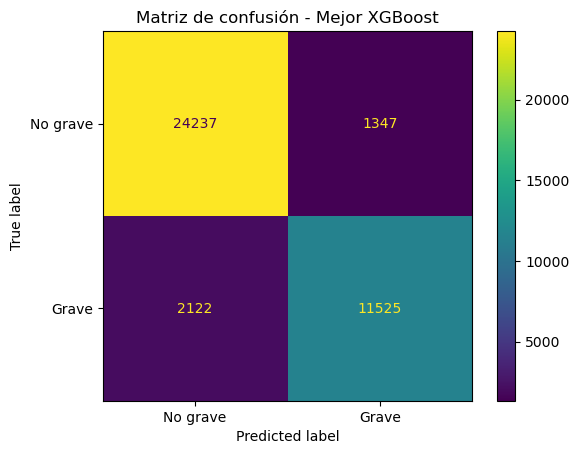

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_mejor_xgb,
    display_labels=["No grave", "Grave"]
)
disp.plot(values_format="d")
plt.title("Matriz de confusión - Mejor XGBoost")
plt.show()

El modelo clasificó correctamente 24.237 siniestros no graves y 11.525 siniestros graves. Esto significa que la mayoría de los casos fueron clasificados correctamente en ambas clases. Sin embargo, también se observan 1.347 falsos positivos, es decir, casos que realmente eran no graves pero el modelo clasificó como graves. En una aplicación de priorización de riesgo, este tipo de error puede implicar que algunos casos reciban una alerta o atención preventiva aunque no sean graves. Por otro lado, hubo 2.122 falsos negativos, es decir, casos que realmente eran graves pero fueron clasificados como no graves.

### Importancia de variables del mejor modelo XGBoost

XGBoost permite identificar qué variables tuvieron mayor peso en la clasificación.

In [69]:
importancias = mejor_modelo_xgb.feature_importances_
df_importancias_xgb = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

df_importancias_xgb.head(20)

,variable,importancia
1,CHOQUE,0.328551
70,condicion_principal_CONDUCTOR,0.112934
131,codigo_causa_principal_121.0,0.047500
14,num_actores,0.037797
113,codigo_causa_principal_103.0,0.033797
52,DISENO_LUGAR_2,0.032998
122,codigo_causa_principal_112.0,0.023281
144,codigo_causa_principal_134.0,0.020827
89,servicio_principal_3.0,0.018978
20,num_vehiculos,0.018666


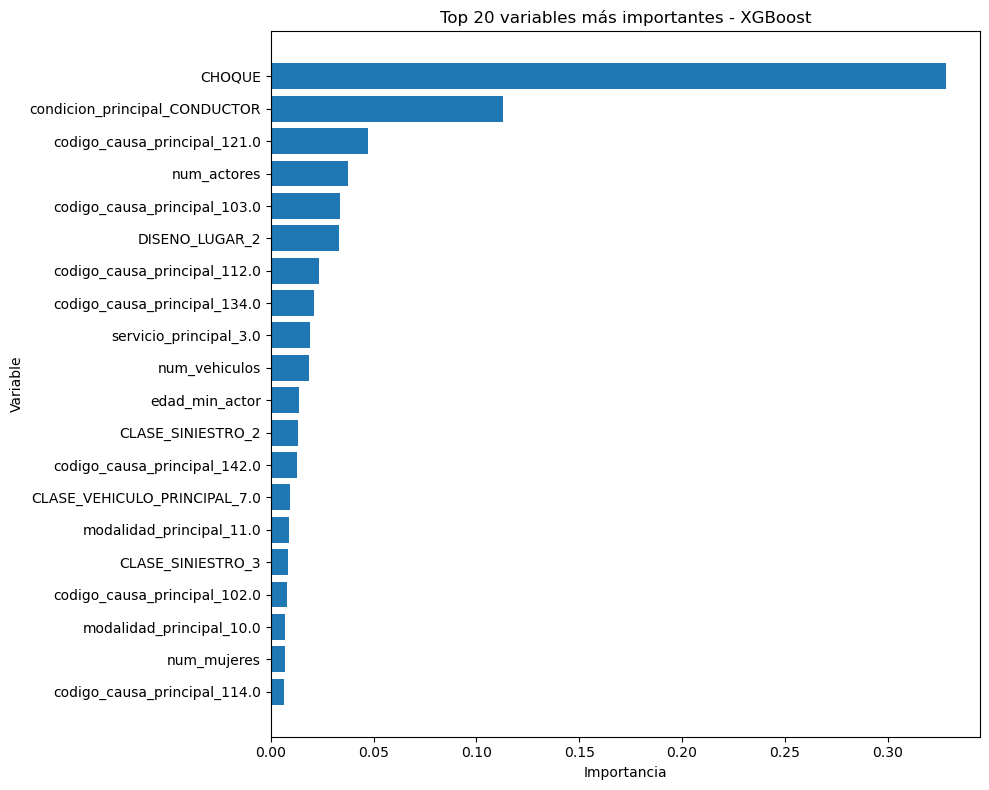

In [70]:
# Gráfico de las 20 variables más importantes
top_n = 20
df_top_importancias = df_importancias_xgb.head(top_n).sort_values(
    by="importancia",
    ascending=True
)
plt.figure(figsize=(10, 8))
plt.barh(df_top_importancias["variable"], df_top_importancias["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables más importantes - XGBoost")
plt.tight_layout()
plt.show()

### Análisis de scale_pos_weight: Ponderar la clase grave ayudó o no?

In [71]:
# Comparación del efecto de scale_pos_weight
df_analisis_spw = df_cv_resumen.copy()

df_analisis_spw["usa_balanceo_clase"] = np.where(
    df_analisis_spw["param_scale_pos_weight"].astype(float) == 1.0,
    "Sin ponderación",
    "Con scale_pos_weight"
)
resumen_spw = df_analisis_spw.groupby("usa_balanceo_clase").agg(
    f1_grave_promedio=("mean_test_f1_grave", "mean"),
    recall_grave_promedio=("mean_test_recall_grave", "mean"),
    precision_grave_promedio=("mean_test_precision_grave", "mean"),
    roc_auc_promedio=("mean_test_roc_auc", "mean"),
    pr_auc_promedio=("mean_test_pr_auc", "mean"),
    cantidad_configuraciones=("mean_test_f1_grave", "count")
).reset_index()
resumen_spw

,usa_balanceo_clase,f1_grave_promedio,recall_grave_promedio,precision_grave_promedio,roc_auc_promedio,pr_auc_promedio,cantidad_configuraciones
0,Con scale_pos_weight,0.864092,0.823913,0.909329,0.953541,0.941377,31
1,Sin ponderación,0.861814,0.789613,0.949106,0.954263,0.942795,19


Con scale_pos_weight, el recall promedio de la clase grave fue 0.8239, mientras que sin ponderación fue 0.7896. Esto significa que ponderar la clase grave ayudó a identificar una mayor proporción de siniestros realmente graves.

Sin embargo, esta mejora en recall viene acompañada de una reducción en precision. Las configuraciones sin ponderación alcanzaron una precision promedio de 0.9491, mientras que las configuraciones con scale_pos_weight tuvieron una precision promedio de 0.9093. Esto indica que, al darle más peso a la clase grave, el modelo tiende a clasificar más casos como graves, aumentando los verdaderos positivos, pero también generando más falsos positivos.

Para SiniBogotá, el uso de scale_pos_weight es pertinente porque el objetivo es priorizar la detección de siniestros graves.

### Ajuste de umbral para el mejor modelo XGBoost

In [72]:
# Probabilidades predichas para la clase grave
y_proba_mejor_xgb = mejor_modelo_xgb.predict_proba(X_test)[:, 1]

# Umbrales a evaluar
umbrales = np.arange(0.20, 0.81, 0.05)
resultados_umbrales = []

for umbral in umbrales:
    y_pred_umbral = (y_proba_mejor_xgb >= umbral).astype(int)
    resultados_umbrales.append({
        "umbral": umbral,
        "accuracy": accuracy_score(y_test, y_pred_umbral),
        "precision_grave": precision_score(y_test, y_pred_umbral, pos_label=1, zero_division=0),
        "recall_grave": recall_score(y_test, y_pred_umbral, pos_label=1, zero_division=0),
        "f1_grave": f1_score(y_test, y_pred_umbral, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_mejor_xgb),
        "pr_auc": average_precision_score(y_test, y_proba_mejor_xgb)
    })
df_umbrales_xgb = pd.DataFrame(resultados_umbrales)
df_umbrales_xgb.sort_values(by="f1_grave", ascending=False)

,umbral,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc
7,0.55,0.913487,0.914397,0.828900,0.869552,0.958488,0.946603
6,0.50,0.911575,0.895354,0.844508,0.869188,0.958488,0.946603
8,0.60,0.914481,0.929980,0.815564,0.869022,0.958488,0.946603
9,0.65,0.914302,0.942213,0.802887,0.866988,0.958488,0.946603
5,0.45,0.907191,0.872136,0.859163,0.865601,0.958488,0.946603
10,0.70,0.913257,0.951516,0.790943,0.863831,0.958488,0.946603
11,0.75,0.912085,0.958214,0.781344,0.860787,0.958488,0.946603
4,0.40,0.900589,0.843132,0.877482,0.859964,0.958488,0.946603
12,0.80,0.909995,0.963696,0.770279,0.856200,0.958488,0.946603
3,0.35,0.890265,0.810077,0.894189,0.850057,0.958488,0.946603


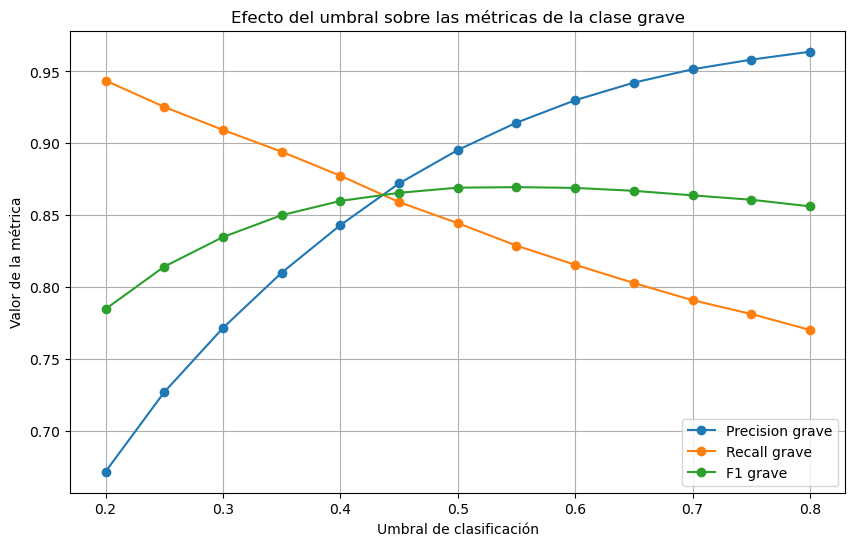

In [73]:
# Visualización del efecto del umbral
plt.figure(figsize=(10, 6))
plt.plot(df_umbrales_xgb["umbral"], df_umbrales_xgb["precision_grave"], marker="o", label="Precision grave")
plt.plot(df_umbrales_xgb["umbral"], df_umbrales_xgb["recall_grave"], marker="o", label="Recall grave")
plt.plot(df_umbrales_xgb["umbral"], df_umbrales_xgb["f1_grave"], marker="o", label="F1 grave")

plt.xlabel("Umbral de clasificación")
plt.ylabel("Valor de la métrica")
plt.title("Efecto del umbral sobre las métricas de la clase grave")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
# Selección del mejor umbral según F1 de la clase grave
idx_mejor_umbral = df_umbrales_xgb["f1_grave"].idxmax()
mejor_umbral = df_umbrales_xgb.loc[idx_mejor_umbral, "umbral"]
print("Mejor umbral según F1 grave:", mejor_umbral)
display(df_umbrales_xgb.loc[[idx_mejor_umbral]])

Mejor umbral según F1 grave: 0.5499999999999999


,umbral,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc
7,0.55,0.913487,0.914397,0.8289,0.869552,0.958488,0.946603


In [75]:
# Evaluación final con el mejor umbral
y_pred_xgb_umbral = (y_proba_mejor_xgb >= mejor_umbral).astype(int)
print("Matriz de confusión con mejor umbral:")
matriz_umbral = confusion_matrix(y_test, y_pred_xgb_umbral)
print(matriz_umbral)

print("\nReporte de clasificación con mejor umbral:")
print(classification_report(
    y_test,
    y_pred_xgb_umbral,
    target_names=["No grave", "Grave"]
))
metricas_xgb_umbral = {
    "modelo": "XGBoost_optimizado_umbral",
    "umbral": mejor_umbral,
    "accuracy": accuracy_score(y_test, y_pred_xgb_umbral),
    "precision_grave": precision_score(y_test, y_pred_xgb_umbral, pos_label=1, zero_division=0),
    "recall_grave": recall_score(y_test, y_pred_xgb_umbral, pos_label=1, zero_division=0),
    "f1_grave": f1_score(y_test, y_pred_xgb_umbral, pos_label=1, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_mejor_xgb),
    "pr_auc": average_precision_score(y_test, y_proba_mejor_xgb)
}
pd.DataFrame([metricas_xgb_umbral])

Matriz de confusión con mejor umbral:
[[24525  1059]
 [ 2335 11312]]

Reporte de clasificación con mejor umbral:
              precision    recall  f1-score   support

    No grave       0.91      0.96      0.94     25584
       Grave       0.91      0.83      0.87     13647

    accuracy                           0.91     39231
   macro avg       0.91      0.89      0.90     39231
weighted avg       0.91      0.91      0.91     39231



,modelo,umbral,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc
0,XGBoost_optimizado_umbral,0.55,0.913487,0.914397,0.8289,0.869552,0.958488,0.946603


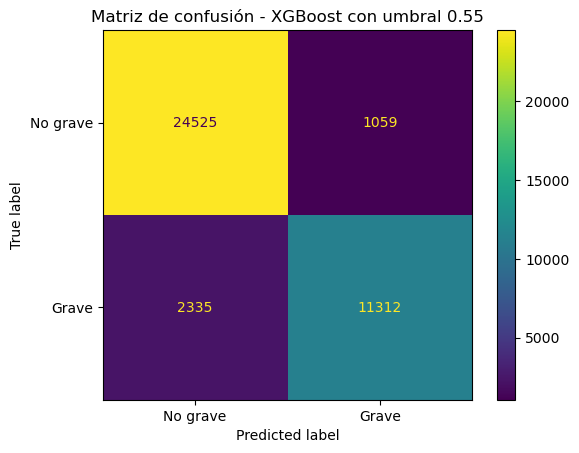

In [76]:
# Matriz de confusión con mejor umbral
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_umbral,
    display_labels=["No grave", "Grave"]
)
disp.plot(values_format="d")
plt.title(f"Matriz de confusión - XGBoost con umbral {mejor_umbral:.2f}")
plt.show()

El ajuste de umbral mostró que el mejor valor según F1-score fue 0.55, alcanzando un F1 de 0.8696 para la clase grave. Sin embargo, la mejora frente al umbral estándar de 0.50 fue mínima, ya que el F1 pasó de 0.8692 a 0.8696. Aunque el umbral 0.55 aumentó la precision de la clase grave, también redujo el recall de 0.8445 a 0.8289.

Esta reducción del recall implica que el modelo dejó de identificar una mayor cantidad de siniestros graves. En la matriz de confusión, los falsos negativos aumentaron de 2.122 con umbral 0.50 a 2.335 con umbral 0.55. Por esta razón, para el contexto de SiniBogotá se considera más adecuado conservar el umbral 0.50, ya que mantiene una mejor capacidad de detección de casos graves sin sacrificar de forma significativa el desempeño global del modelo.

In [77]:
""" Guardar resultados del experimento XGBoost
df_resultados_xgb.to_csv("resultados_xgboost_resumen.csv", index=False)
df_cv_resumen.to_csv("resultados_xgboost_cv_configuraciones.csv", index=False)
df_importancias_xgb.to_csv("importancias_xgboost.csv", index=False)
print("Archivos guardados:")
print("- resultados_xgboost_resumen.csv")
print("- resultados_xgboost_cv_configuraciones.csv")
print("- importancias_xgboost.csv") """

' Guardar resultados del experimento XGBoost\ndf_resultados_xgb.to_csv("resultados_xgboost_resumen.csv", index=False)\ndf_cv_resumen.to_csv("resultados_xgboost_cv_configuraciones.csv", index=False)\ndf_importancias_xgb.to_csv("importancias_xgboost.csv", index=False)\nprint("Archivos guardados:")\nprint("- resultados_xgboost_resumen.csv")\nprint("- resultados_xgboost_cv_configuraciones.csv")\nprint("- importancias_xgboost.csv") '

### **Conclusión general**

El modelo XGBoost mostró un desempeño alto y estable para la clasificación binaria de la gravedad de los siniestros viales en SiniBogotá. A partir de la búsqueda aleatoria de hiperparámetros con validación cruzada estratificada, se identificaron configuraciones con F1-score cercano a 0.87 para la clase grave, manteniendo además valores altos de ROC-AUC y PR-AUC.

El mejor modelo seleccionado fue el entrenado con semilla 42, el cual alcanzó en el conjunto de prueba una exactitud de 0.9116, precision de 0.8954, recall de 0.8445 y F1-score de 0.8692 para la clase grave. Estos resultados indican que el modelo logra un equilibrio adecuado entre identificar siniestros graves y evitar clasificar incorrectamente demasiados casos no graves como graves.

El uso de `scale_pos_weight` permitió evaluar el efecto de ponderar la clase grave. Los resultados mostraron que las configuraciones con ponderación tuvieron un recall promedio superior al de las configuraciones sin ponderación, lo que indica que esta estrategia ayuda a detectar más casos graves. Sin embargo, también se observó una reducción en precision, lo cual refleja el compromiso natural entre detectar más positivos y aumentar los falsos positivos.

La comparación entre las semillas 42 y 2026 mostró resultados muy similares, lo que sugiere que el modelo es estable ante cambios en la aleatoriedad del proceso de búsqueda y entrenamiento. Esto es importante porque indica que el desempeño obtenido no depende únicamente de una semilla específica.

El ajuste de umbral evidenció que el umbral 0.55 obtiene un F1-score ligeramente superior, pero con una reducción del recall de la clase grave. Dado que el aumento del F1 fue mínimo y que el objetivo del proyecto está relacionado con la identificación de siniestros graves, se considera más conveniente mantener el umbral estándar de 0.50 para conservar una mayor capacidad de detección de casos graves.

En términos generales, XGBoost se presenta como un modelo competitivo para SiniBogotá, ya que combina buen desempeño predictivo, estabilidad y posibilidad de interpretación mediante importancia de variables. Además, al trabajar adecuadamente con datos tabulares y relaciones no lineales, resulta apropiado para capturar patrones asociados con condiciones del siniestro, actores involucrados, vehículos, hipótesis, clima y variables temporales.

In [78]:
# ============================================================
# EXPORTACIÓN DEL MODELO XGBOOST PARA DESPLIEGUE
# SiniBogotá
# ============================================================

import joblib
import json
from pathlib import Path

# Carpeta de salida
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 1. Verificaciones mínimas
# ------------------------------------------------------------

objetos_requeridos = [
    "mejor_modelo_xgb",
    "X",
    "X_train",
    "cat_cols",
    "cols_binarias",
    "cols_categoricas_codificadas"
]

for obj in objetos_requeridos:
    if obj not in globals():
        raise NameError(f"No existe la variable requerida: {obj}")

print("Todas las variables requeridas existen.")

# ------------------------------------------------------------
# 2. Definir umbral final
# ------------------------------------------------------------

if "mejor_umbral" in globals():
    UMBRAL_FINAL = float(mejor_umbral)
else:
    UMBRAL_FINAL = 0.50

print("Umbral final exportado:", UMBRAL_FINAL)

# ------------------------------------------------------------
# 3. Columnas finales del modelo
# ------------------------------------------------------------
# Estas son las columnas one-hot reales usadas por XGBoost.

feature_columns = X_train.columns.tolist()

print("Número de columnas finales del modelo:", len(feature_columns))

# ------------------------------------------------------------
# 4. Columnas antes del one-hot encoding
# ------------------------------------------------------------
# Estas son las columnas que debería recibir el backend de la app, antes de convertirlas a las 206 columnas finales.

raw_input_columns = X.columns.tolist()

print("Número de columnas antes de one-hot:", len(raw_input_columns))
print("Columnas antes de one-hot:")
print(raw_input_columns)

# ------------------------------------------------------------
# 5. Valores por defecto
# ------------------------------------------------------------
# Sirven para completar variables que la app no le pida al usuario.
# Numéricas: mediana
# Categóricas: moda

default_values = {}

for col in raw_input_columns:
    if col in cat_cols:
        moda = X[col].mode(dropna=True)
        if len(moda) > 0:
            default_values[col] = moda.iloc[0]
        else:
            default_values[col] = None
    else:
        if pd.api.types.is_numeric_dtype(X[col]):
            default_values[col] = X[col].median()
        else:
            moda = X[col].mode(dropna=True)
            if len(moda) > 0:
                default_values[col] = moda.iloc[0]
            else:
                default_values[col] = None

# ------------------------------------------------------------
# 6. Opciones para dropdowns en la app
# ------------------------------------------------------------
# Para columnas categóricas se guardan los valores únicos.
# Para columnas numéricas se guarda mínimo, máximo y mediana.

dropdown_options = {}

for col in raw_input_columns:
    if col in cat_cols:
        valores = (
            X[col]
            .dropna()
            .astype(str)
            .sort_values()
            .unique()
            .tolist()
        )
        dropdown_options[col] = valores

numeric_ranges = {}

for col in raw_input_columns:
    if col not in cat_cols and pd.api.types.is_numeric_dtype(X[col]):
        numeric_ranges[col] = {
            "min": float(X[col].min()),
            "max": float(X[col].max()),
            "median": float(X[col].median())
        }

# ------------------------------------------------------------
# 7. Función auxiliar para convertir objetos numpy/pandas a JSON
# ------------------------------------------------------------

def convertir_a_json_serializable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    elif pd.isna(obj):
        return None
    else:
        return obj

default_values_json = {
    k: convertir_a_json_serializable(v)
    for k, v in default_values.items()
}

# ------------------------------------------------------------
# 8. Guardar artefacto principal
# ------------------------------------------------------------
# Este archivo .joblib lo usará el backend Python.
# Contiene el modelo y todo lo necesario para reconstruir las columnas.

artifacts = {
    "model": mejor_modelo_xgb,
    "feature_columns": feature_columns,
    "raw_input_columns": raw_input_columns,
    "cat_cols": cat_cols,
    "cols_binarias": cols_binarias,
    "cols_categoricas_codificadas": cols_categoricas_codificadas,
    "default_values": default_values,
    "threshold": UMBRAL_FINAL,
    "target": "GRAVEDAD_BIN",
    "positive_class": 1,
    "positive_class_label": "Grave",
    "negative_class_label": "No grave"
}

joblib.dump(
    artifacts,
    ARTIFACT_DIR / "sinibogota_xgb_artifacts.joblib"
)

# ------------------------------------------------------------
# 9. Guardar metadatos livianos en JSON
# ------------------------------------------------------------
# Este JSON sirve para revisar el modelo y construir formularios

metadata = {
    "model_name": "SiniBogota_XGBoost",
    "model_type": "XGBClassifier",
    "target": "GRAVEDAD_BIN",
    "positive_class": "Grave",
    "negative_class": "No grave",
    "threshold": UMBRAL_FINAL,
    "n_features_model": len(feature_columns),
    "feature_columns": feature_columns,
    "raw_input_columns": raw_input_columns,
    "cat_cols": cat_cols,
    "cols_binarias": cols_binarias,
    "cols_categoricas_codificadas": cols_categoricas_codificadas,
    "default_values": default_values_json,
    "dropdown_options": dropdown_options,
    "numeric_ranges": numeric_ranges
}

with open(
    ARTIFACT_DIR / "sinibogota_xgb_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("\nArtefactos guardados correctamente:")
print("- artifacts/sinibogota_xgb_artifacts.joblib")
print("- artifacts/sinibogota_xgb_metadata.json")

Todas las variables requeridas existen.
Umbral final exportado: 0.5499999999999999
Número de columnas finales del modelo: 206
Número de columnas antes de one-hot: 36
Columnas antes de one-hot:
['HORA', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'condicion_principal', 'num_vehiculos', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']

Artefactos guardados correctamente:
- artifacts/sinibogota_xgb_artifacts.joblib
- artifacts/sinibogota_xgb_metadata.json


In [79]:
# PRUEBA DE CARGA DEL MODELO EXPORTADO

import re
artifact_path = "artifacts/sinibogota_xgb_artifacts.joblib"
artifacts_loaded = joblib.load(artifact_path)

modelo = artifacts_loaded["model"]
feature_columns = artifacts_loaded["feature_columns"]
raw_input_columns = artifacts_loaded["raw_input_columns"]
cat_cols_loaded = artifacts_loaded["cat_cols"]
cols_binarias_loaded = artifacts_loaded["cols_binarias"]
cols_categoricas_codificadas_loaded = artifacts_loaded["cols_categoricas_codificadas"]
default_values_loaded = artifacts_loaded["default_values"]
threshold_loaded = artifacts_loaded["threshold"]

print("Modelo cargado correctamente.")
print("Número de columnas esperadas por el modelo:", len(feature_columns))
print("Umbral cargado:", threshold_loaded)

def limpiar_nombre_columna(col):
    col = str(col)
    col = re.sub(r"[\[\]<>]", "_", col)
    col = re.sub(r"\s+", "_", col)
    return col

def preparar_entrada_para_xgboost(input_data, artifacts):
    """
    Convierte un diccionario de entrada de la app en la matriz final
    de 206 columnas esperada por el modelo XGBoost.
    input_data:
        Diccionario con algunas o todas las variables de raw_input_columns.
    artifacts:
        Diccionario cargado desde sinibogota_xgb_artifacts.joblib.
    """
    feature_columns = artifacts["feature_columns"]
    raw_input_columns = artifacts["raw_input_columns"]
    cat_cols = artifacts["cat_cols"]
    cols_binarias = artifacts["cols_binarias"]
    cols_categoricas_codificadas = artifacts["cols_categoricas_codificadas"]
    default_values = artifacts["default_values"]

    # 1. Crear fila base con valores por defecto
    fila = default_values.copy()

    # 2. Sobrescribir con los valores enviados por la app
    for key, value in input_data.items():
        if key in fila:
            fila[key] = value

    # 3. Crear DataFrame con todas las columnas originales del modelo
    df_user = pd.DataFrame([fila])
    df_user = df_user.reindex(columns=raw_input_columns)

    # 4. Transformar columnas binarias si llegan como texto
    for col in cols_binarias:
        if col in df_user.columns:
            if df_user[col].dtype == "object":
                df_user[col] = (
                    df_user[col]
                    .astype(str)
                    .str.strip()
                    .str.upper()
                    .map({"SI": 1, "NO": 0, "1": 1, "0": 0})
                    .fillna(0)
                )
            else:
                df_user[col] = pd.to_numeric(df_user[col], errors="coerce").fillna(0)

    # 5. Asegurar que las variables categóricas codificadas se traten como categorías
    for col in cols_categoricas_codificadas:
        if col in df_user.columns:
            df_user[col] = df_user[col].astype("object")

    # 6. Asegurar que las demás categóricas sean object
    for col in cat_cols:
        if col in df_user.columns:
            df_user[col] = df_user[col].astype("object")

    # 7. One-hot encoding igual que en entrenamiento
    df_encoded = pd.get_dummies(
        df_user,
        columns=cat_cols,
        drop_first=True
    )

    # 8. Convertir columnas booleanas a 0/1
    bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
    df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

    # 9. Limpiar nombres igual que en entrenamiento
    df_encoded.columns = [
        limpiar_nombre_columna(col)
        for col in df_encoded.columns
    ]

    # 10. Reindexar a las 206 columnas exactas del modelo
    df_encoded = df_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # 11. Asegurar formato numérico
    for col in df_encoded.columns:
        df_encoded[col] = pd.to_numeric(df_encoded[col], errors="coerce")
    return df_encoded

def predecir_gravedad_siniestro(input_data, artifacts):
    modelo = artifacts["model"]
    threshold = artifacts["threshold"]
    X_user = preparar_entrada_para_xgboost(input_data, artifacts)
    proba_grave = float(modelo.predict_proba(X_user)[0, 1])
    pred_binaria = int(proba_grave >= threshold)

    resultado = {
        "prediccion_binaria": pred_binaria,
        "prediccion_texto": "Grave" if pred_binaria == 1 else "No grave",
        "probabilidad_grave": proba_grave,
        "probabilidad_no_grave": 1 - proba_grave,
        "umbral": threshold
    }
    return resultado

# Prueba con valores por defecto
ejemplo = {}
resultado = predecir_gravedad_siniestro(
    ejemplo,
    artifacts_loaded
)
print("\nResultado de prueba con valores por defecto:")
print(resultado)

X_prueba = preparar_entrada_para_xgboost(ejemplo, artifacts_loaded)
print("\nShape final enviado al modelo:", X_prueba.shape)

Modelo cargado correctamente.
Número de columnas esperadas por el modelo: 206
Umbral cargado: 0.5499999999999999

Resultado de prueba con valores por defecto:
{'prediccion_binaria': 1, 'prediccion_texto': 'Grave', 'probabilidad_grave': 0.7952556014060974, 'probabilidad_no_grave': 0.2047443985939026, 'umbral': 0.5499999999999999}

Shape final enviado al modelo: (1, 206)
